In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

%cd ..
from src.database import engine

query="""
    SELECT 
    p.subject_id,
    p.gender,
    p.anchor_age,
    p.anchor_year,

    a.hadm_id, 
    a.admittime,
    a.dischtime,
    a.admission_type,
    a.admission_location,
    a.discharge_location,
    a.insurance,
    a.language,
    a.marital_status,
    a.race,
    a.hospital_expire_flag

    from patients p
    join admissions a
        on p.subject_id = a.subject_id
"""

df = pd.read_sql(query, engine)
df.head()

/Users/frank/Data Science Projects/Healthcare-Demand-Forecasting


/Users/frank/DataLearning/dsenve/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,hospital_expire_flag
0,10004235,M,47,2196,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,0
1,10009628,M,58,2153,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,0
2,10018081,M,79,2133,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,0
3,10006053,M,52,2111,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,URGENT,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,,UNKNOWN,1
4,10031404,F,82,2113,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,0


In [20]:
df.shape

(275, 15)

In [21]:
df.describe()

,subject_id,anchor_age,anchor_year,hadm_id,hospital_expire_flag
count,2.750000e+02,275.000000,275.000000,2.750000e+02,275.000000
mean,1.001890e+07,61.043636,2151.236364,2.513055e+07,0.054545
std,1.212777e+04,14.440600,24.501723,2.907533e+06,0.227505
min,1.000003e+07,21.000000,2110.000000,2.004459e+07,0.000000
25%,1.000787e+07,52.500000,2134.000000,2.258313e+07,0.000000
50%,1.001808e+07,60.000000,2146.000000,2.517230e+07,0.000000
75%,1.002626e+07,70.000000,2175.000000,2.767155e+07,0.000000
max,1.004002e+07,91.000000,2201.000000,2.997458e+07,1.000000


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   subject_id            275 non-null    int64 
 1   gender                275 non-null    object
 2   anchor_age            275 non-null    int64 
 3   anchor_year           275 non-null    int64 
 4   hadm_id               275 non-null    int64 
 5   admittime             275 non-null    object
 6   dischtime             275 non-null    object
 7   admission_type        275 non-null    object
 8   admission_location    275 non-null    object
 9   discharge_location    275 non-null    object
 10  insurance             275 non-null    object
 11  language              275 non-null    object
 12  marital_status        275 non-null    object
 13  race                  275 non-null    object
 14  hospital_expire_flag  275 non-null    int64 
dtypes: int64(5), object(10)
memory usage: 32

In [23]:
df.isnull().sum()
duplicates = df[df.duplicated()]
duplicates.head() 

# since the table below is empty, there are no duplicates

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,hospital_expire_flag


In [24]:
df.isnull().sum()
(df.isnull().mean() * 100).sort_values(ascending=False)

subject_id              0.0
gender                  0.0
anchor_age              0.0
anchor_year             0.0
hadm_id                 0.0
admittime               0.0
dischtime               0.0
admission_type          0.0
admission_location      0.0
discharge_location      0.0
insurance               0.0
language                0.0
marital_status          0.0
race                    0.0
hospital_expire_flag    0.0
dtype: float64

In [25]:
df.drop_duplicates()

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,hospital_expire_flag
0,10004235,M,47,2196,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,0
1,10009628,M,58,2153,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,0
2,10018081,M,79,2133,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,0
3,10006053,M,52,2111,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,URGENT,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,,UNKNOWN,1
4,10031404,F,82,2113,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,10038992,M,70,2185,24745425,2187-07-29 01:05:00,2187-08-03 17:02:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,0
271,10008287,F,43,2145,22168393,2145-09-28 01:17:00,2145-10-02 13:35:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,Other,ENGLISH,SINGLE,WHITE,0
272,10022880,M,66,2177,27708593,2177-03-12 07:15:00,2177-03-19 14:25:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME,Medicare,ENGLISH,MARRIED,WHITE,0
273,10004457,M,65,2140,23251352,2141-12-17 11:00:00,2141-12-21 15:56:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,REHAB,Medicare,ENGLISH,SINGLE,OTHER,0


## EDA

In [26]:
df["admittime"] = pd.to_datetime(df["admittime"])
df["dischtime"] = pd.to_datetime(df["dischtime"])
df.head()

df["Length_of_Stay"] = (
    df["dischtime"] - df["admittime"]
).dt.total_seconds() / (60 * 60 * 24) # fractional days of stay

df.head(10)

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,hospital_expire_flag,Length_of_Stay
0,10004235,M,47,2196,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,0,8.975000
1,10009628,M,58,2153,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,0,7.841667
2,10018081,M,79,2133,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,0,5.731250
3,10006053,M,52,2111,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,URGENT,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,,UNKNOWN,1,1.736806
4,10031404,F,82,2113,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,0,2.090972
5,10005817,M,66,2132,20626031,2132-12-12 01:43:00,2132-12-20 15:04:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicare,ENGLISH,MARRIED,WHITE,0,8.556250
6,10019385,M,44,2180,20297618,2180-02-15 20:28:00,2180-02-25 13:45:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Other,ENGLISH,MARRIED,WHITE,0,9.720139
7,10002495,M,81,2141,24982426,2141-05-22 20:17:00,2141-05-29 17:41:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,UNKNOWN,0,6.891667
8,10038081,F,63,2115,20755971,2115-09-27 20:40:00,2115-10-12 00:00:00,URGENT,TRANSFER FROM HOSPITAL,DIED,Other,?,SINGLE,UNKNOWN,1,14.138889
9,10019917,M,44,2182,22585261,2182-01-07 23:25:00,2182-01-10 16:52:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,SINGLE,OTHER,0,2.727083


In [27]:
df["admission_year"] = df["admittime"].dt.year
df.head()

df["admission_month"] = df["admittime"].dt.month
df.head()

df["admission_week"] = df["admittime"].dt.weekday
df.head()

df["day_of_week"] = df["admittime"].dt.day_name()
df.head()

df["week_num"] = (df["admittime"].dt.day - 1) // 7 + 1
named_weeks = {
    1: "first", 
    2: "second", 
    3: "third", 
    4: "fourth", 
    5: "fifth"
    }
df["week_of_month"] = df["week_num"].map(named_weeks)
df.head()

df["admission_hour"] = df["admittime"].dt.hour
df.head()


,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,...,race,hospital_expire_flag,Length_of_Stay,admission_year,admission_month,admission_week,day_of_week,week_num,week_of_month,admission_hour
0,10004235,M,47,2196,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,BLACK/CAPE VERDEAN,0,8.975000,2196,2,2,Wednesday,4,fourth,14
1,10009628,M,58,2153,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,...,HISPANIC/LATINO - PUERTO RICAN,0,7.841667,2153,9,0,Monday,3,third,17
2,10018081,M,79,2133,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,WHITE,0,5.731250,2134,8,2,Wednesday,3,third,2
3,10006053,M,52,2111,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,URGENT,TRANSFER FROM HOSPITAL,DIED,...,UNKNOWN,1,1.736806,2111,11,4,Friday,2,second,23
4,10031404,F,82,2113,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,URGENT,TRANSFER FROM HOSPITAL,HOME,...,WHITE,0,2.090972,2113,8,4,Friday,1,first,18


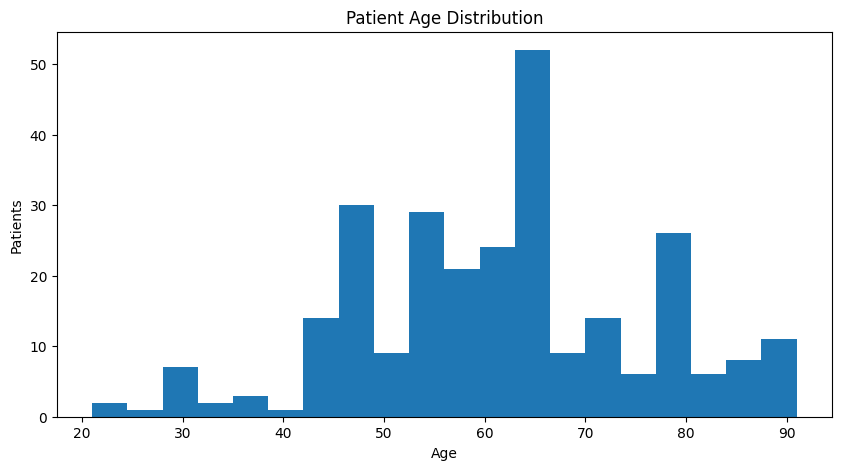

In [28]:
# patient age - how old are the patients? 

plt.figure(figsize=(10,5))
plt.hist(df["anchor_age"], bins=20)
# plt.hist(df["anchor_age"], bins=range(15, 95, 5))
plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Patients")
plt.show()

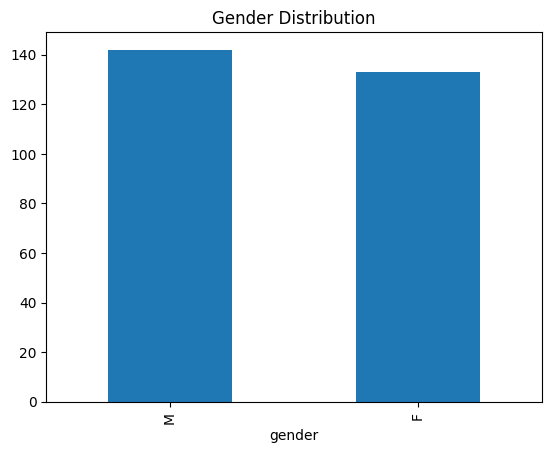

<BarContainer object of 2 artists>

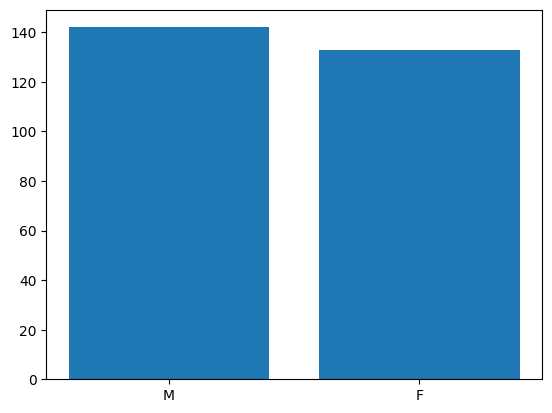

In [29]:
# gender distribution

df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

gender_counts = df["gender"].value_counts()
plt.bar(gender_counts.index, gender_counts.values)


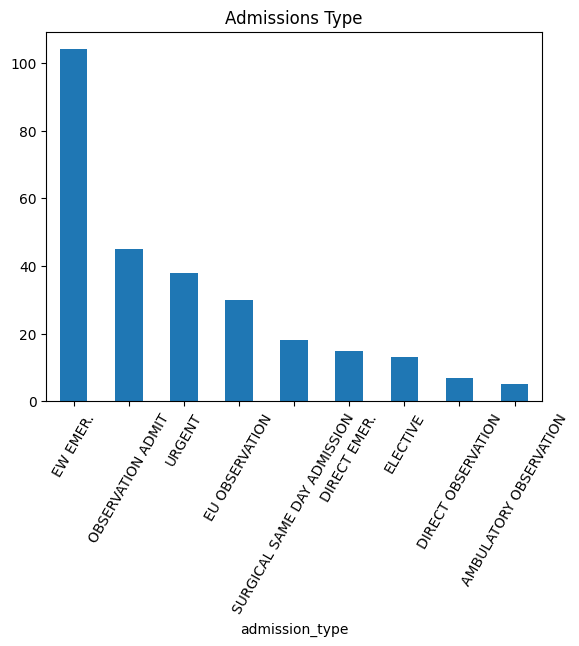

In [30]:
df["admission_type"].value_counts().plot(kind="bar")
plt.title("Admissions Type")
plt.xticks(rotation=60)
plt.show()

<Axes: xlabel='insurance'>

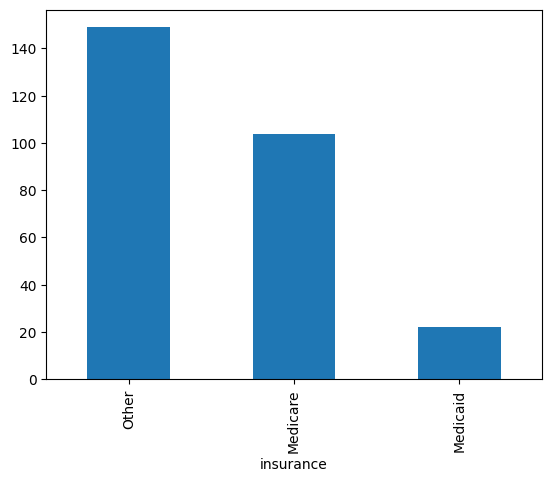

In [31]:
df["insurance"].value_counts().plot(kind="bar")

<Axes: xlabel='race'>

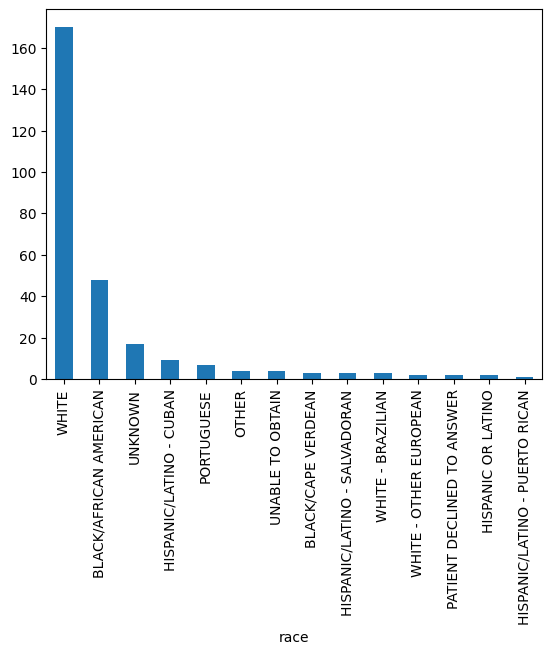

In [32]:
df["race"].value_counts().plot(kind="bar")


In [33]:
df

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,...,race,hospital_expire_flag,Length_of_Stay,admission_year,admission_month,admission_week,day_of_week,week_num,week_of_month,admission_hour
0,10004235,M,47,2196,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,BLACK/CAPE VERDEAN,0,8.975000,2196,2,2,Wednesday,4,fourth,14
1,10009628,M,58,2153,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,...,HISPANIC/LATINO - PUERTO RICAN,0,7.841667,2153,9,0,Monday,3,third,17
2,10018081,M,79,2133,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,WHITE,0,5.731250,2134,8,2,Wednesday,3,third,2
3,10006053,M,52,2111,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,URGENT,TRANSFER FROM HOSPITAL,DIED,...,UNKNOWN,1,1.736806,2111,11,4,Friday,2,second,23
4,10031404,F,82,2113,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,URGENT,TRANSFER FROM HOSPITAL,HOME,...,WHITE,0,2.090972,2113,8,4,Friday,1,first,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,10038992,M,70,2185,24745425,2187-07-29 01:05:00,2187-08-03 17:02:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,...,WHITE,0,5.664583,2187,7,6,Sunday,5,fifth,1
271,10008287,F,43,2145,22168393,2145-09-28 01:17:00,2145-10-02 13:35:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,WHITE,0,4.512500,2145,9,1,Tuesday,4,fourth,1
272,10022880,M,66,2177,27708593,2177-03-12 07:15:00,2177-03-19 14:25:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME,...,WHITE,0,7.298611,2177,3,2,Wednesday,2,second,7
273,10004457,M,65,2140,23251352,2141-12-17 11:00:00,2141-12-21 15:56:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,REHAB,...,OTHER,0,4.205556,2141,12,6,Sunday,3,third,11


Text(0.5, 1.0, 'Length of Hospital Stay')

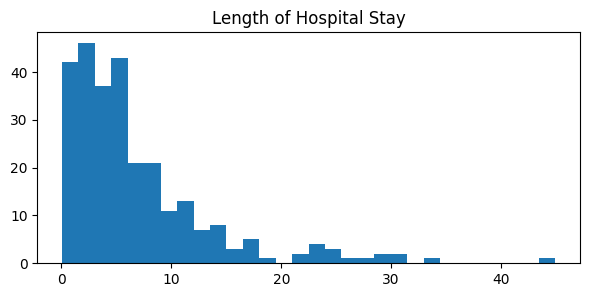

In [34]:
plt.figure(figsize=(7,3))
plt.hist(df["Length_of_Stay"], bins=30)
plt.title("Length of Hospital Stay")

In [35]:
df_no_rowindex = df.groupby("gender")[["Length_of_Stay"]].mean().reset_index()
df_no_rowindex

df.groupby("gender")[["Length_of_Stay"]].agg("mean").reset_index()
df.groupby("gender")[["Length_of_Stay"]].agg(["mean", "max", "min"]).reset_index()
# df.groupby("gender")[["Length_of_Stay"]].agg(average_stay=("Length_of_Stay", "mean")).reset_index()


gender Length_of_Stay                     
                   mean        max       min
0      F       6.240320  34.080556  0.046528
1      M       7.470481  44.927778  0.125000

In [36]:
df.groupby("admission_type")[["Length_of_Stay"]].mean().reset_index()

,admission_type,Length_of_Stay
0,AMBULATORY OBSERVATION,1.015278
1,DIRECT EMER.,9.389676
2,DIRECT OBSERVATION,1.445139
3,ELECTIVE,8.190759
4,EU OBSERVATION,0.916921
5,EW EMER.,7.279320
6,OBSERVATION ADMIT,8.151821
7,SURGICAL SAME DAY ADMISSION,5.696258
8,URGENT,9.850841


In [37]:
df.groupby("insurance")[["Length_of_Stay"]].mean().reset_index()

,insurance,Length_of_Stay
0,Medicaid,6.452904
1,Medicare,6.381003
2,Other,7.283105


In [38]:
df_mean = df.groupby("admission_type")[["hospital_expire_flag"]].agg("mean").reset_index()
df_mean["hospital_expire_flag"] = df_mean["hospital_expire_flag"] * 100
df_mean

,admission_type,hospital_expire_flag
0,AMBULATORY OBSERVATION,0.000000
1,DIRECT EMER.,6.666667
2,DIRECT OBSERVATION,0.000000
3,ELECTIVE,0.000000
4,EU OBSERVATION,0.000000
5,EW EMER.,5.769231
6,OBSERVATION ADMIT,6.666667
7,SURGICAL SAME DAY ADMISSION,0.000000
8,URGENT,13.157895


Text(0, 0.5, "Patient's Length of Stay")

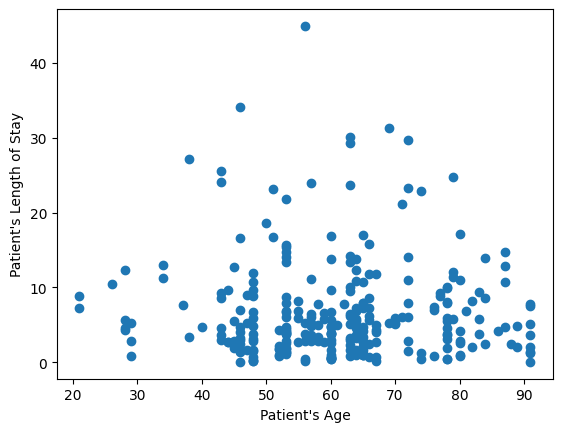

In [39]:
plt.scatter(
    df["anchor_age"],
    df["Length_of_Stay"]
)
plt.xlabel("Patient's Age")
plt.ylabel("Patient's Length of Stay")


- There doesn't seem to be a correlation between age and length of stay

In [40]:
df[["anchor_age","Length_of_Stay"]].corr()

,anchor_age,Length_of_Stay
anchor_age,1.000000,-0.027647
Length_of_Stay,-0.027647,1.000000


In [41]:
# extra queries

query="""
    SELECT *
    FROM patients
"""

patients = pd.read_sql(query, engine)

query="""
    SELECT *
    FROM admissions
""" 

admissions = pd.read_sql(query, engine)



In [42]:
# python to join the two different tables: patients and admissions
df1 = patients.merge(
    admissions,
    on="subject_id",
    how="inner"
)

# display(df.style.hide())
df1.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,hadm_id,admittime,dischtime,deathtime,...,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10014729,F,21,2125,2011 - 2013,,23300884,2125-03-19 16:58:00,2125-03-28 13:37:00,,...,P76K54,EMERGENCY ROOM,HOME HEALTH CARE,Other,ENGLISH,SINGLE,WHITE - OTHER EUROPEAN,2125-03-19 12:36:00,2125-03-19 18:45:00,0
1,10014729,F,21,2125,2011 - 2013,,28889419,2125-02-27 07:15:00,2125-03-06 14:25:00,,...,P17BJ5,PHYSICIAN REFERRAL,HOME HEALTH CARE,Other,ENGLISH,SINGLE,WHITE - OTHER EUROPEAN,,,0
2,10003400,F,72,2134,2011 - 2013,2137-09-02,23559586,2137-08-04 00:07:00,2137-09-02 17:05:00,2137-09-02 17:05:00,...,P99U21,TRANSFER FROM HOSPITAL,DIED,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,,,1
3,10003400,F,72,2134,2011 - 2013,2137-09-02,20214994,2137-02-24 10:00:00,2137-03-19 15:45:00,,...,P60ZCO,TRANSFER FROM SKILLED NURSING FACILITY,CHRONIC/LONG TERM ACUTE CARE,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,,,0
4,10003400,F,72,2134,2011 - 2013,2137-09-02,27296885,2136-12-31 21:40:00,2137-01-03 17:05:00,,...,P14622,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,2136-12-31 13:41:00,2137-01-01 00:35:00,0


# Statistical Analysis
## Objective

The exploratory analysis identified several intersting patterns within the MIMIC-IV clinical dataset. This section evaluates whether those patterns are statistically meaningful using hypothesis testing and correlation analysis. Rather than relying solely on visualizations, inferential statistics allow us to determine whether observed differences are likely due to random variation or represent meaningful relationships within the patient population. The analyses performed in this secton focus on questions relevant to hospital operations and clinical decision making. The statistical analyses include:

1. Relationship between age and hospital length of stay
2. Comparison of emergency vs elective admissions
3. Comparison of hospital stay by gender
4. Comparison pf hospital stay across admission types
5. Relationship between age and in-hospital morality
6. Comparison of hospital stay across insurance groups
7. Outlier analysis



In [43]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Research Question 1
### Business Question
### Does patient age influence hospital length of stay? 
Hospital administrators often expect that older patients require more complex care and therefore remain admitted longer. 
### Null Hypothesis (H0)
There is no statistically significant relationship between patient age and hospital length of stay.
### Alternative Hypothesis (H1)
Older patients tend to remain hospitalized longer.

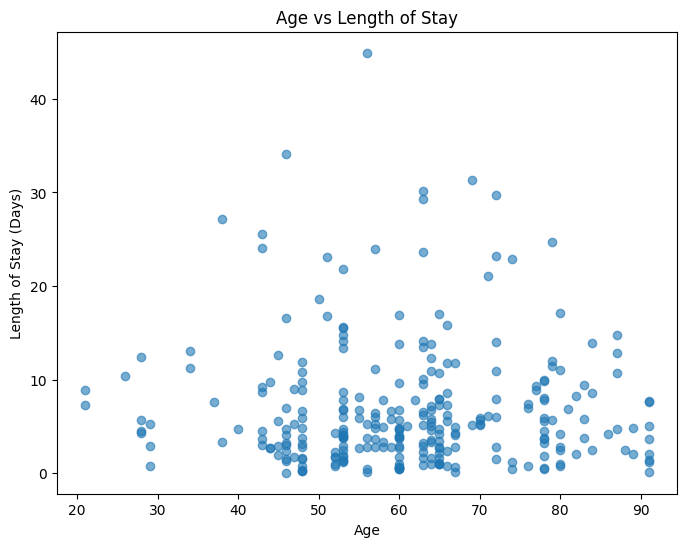

In [44]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["anchor_age"],
    df["Length_of_Stay"],
    alpha=0.6
)

plt.title("Age vs Length of Stay")
plt.xlabel("Age")
plt.ylabel("Length of Stay (Days)")
plt.grid(False)

In [45]:
correlation, p_value = stats.pearsonr(
    df["anchor_age"],
    df["Length_of_Stay"]
)

print(f"Correlation coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.5f}")


Correlation coefficient: -0.028
P-value: 0.64805


### Interpretation
The Pearson correlation coefficient is -0.028 with a p-value of 0.64805. 
Interpret the relationship: 
- Weak / Moderate / Strong
- Positive / Negative

If the p-value is below 0.05: 

"The relationship is statistically significant."

Otherwise: 

"The relationship is not statistically significant."

### Business Impact
Understanding whether age influences hospital stay helps healthcare administrators estimate bed occupancy and allocate clinical resources.

## Research Question 2
### Do emergency admissions have longer hospital stays than elective admissions? 
Hospitals allocate different resources depending on admission type. This analysis compares the average hospital stay between emergency and elective admissions. 

In [46]:
emergency = df[
    df["admission_type"] == "EW EMER."
][["Length_of_Stay"]]

emergency

,Length_of_Stay
51,8.860417
52,11.813889
53,6.216667
54,3.804167
55,3.605556
...,...
151,12.385417
152,0.756944
153,17.090278
154,2.834028


In [47]:
elective = df[
    df["admission_type"] == "ELECTIVE"
][["Length_of_Stay"]]

elective

,Length_of_Stay
38,5.100694
39,5.291667
40,7.350694
41,6.188194
42,3.260417
43,9.221528
44,4.270833
45,23.683333
46,6.511111
47,16.999306


/var/folders/xf/n8m4p5pj34v3rqg175l87xp40000gn/T/ipykernel_64323/3552942133.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


Text(0.5, 1.0, 'Emergency vs Elective Admissions')

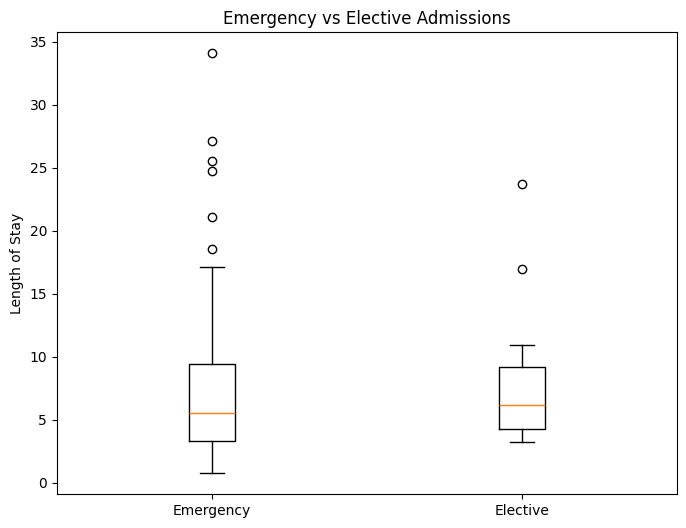

In [48]:
plt.figure(figsize=(8,6))

plt.boxplot(
    [emergency["Length_of_Stay"], elective["Length_of_Stay"]],
    labels=["Emergency", "Elective"]
)

plt.ylabel("Length of Stay")
plt.title("Emergency vs Elective Admissions")


In [49]:
t_statistic, p_value = stats.ttest_ind(
    emergency, 
    elective,
    equal_var=False
)

t_statistic, p_value = stats.ttest_ind(
    emergency["Length_of_Stay"],
    elective["Length_of_Stay"],
    equal_var=False
)

print(f"T-statistic: {t_statistic:.5f}")
print(f"P-value: {p_value:.5f}")

T-statistic: -0.51811
P-value: 0.61187


Interpretation follows the same structure as Question 1.

## Research Question 3
### Does gender influence hospital length of stay? 

Although differences may exist across patient groups, statistical testing is required to determine whether observed differences are meaningful.

In [50]:
male = df[
    df["gender"] == "M"
][["Length_of_Stay"]]

male

,Length_of_Stay
0,8.975000
1,7.841667
2,5.731250
3,1.736806
5,8.556250
...,...
269,1.385417
270,5.664583
272,7.298611
273,4.205556


In [51]:
female = df[
    df["gender"] == "F"
][["Length_of_Stay"]]

female

,Length_of_Stay
4,2.090972
8,14.138889
17,16.619444
18,0.786111
19,4.190972
...,...
261,9.447917
263,6.072917
264,1.625000
268,4.048611


/var/folders/xf/n8m4p5pj34v3rqg175l87xp40000gn/T/ipykernel_64323/3856034927.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


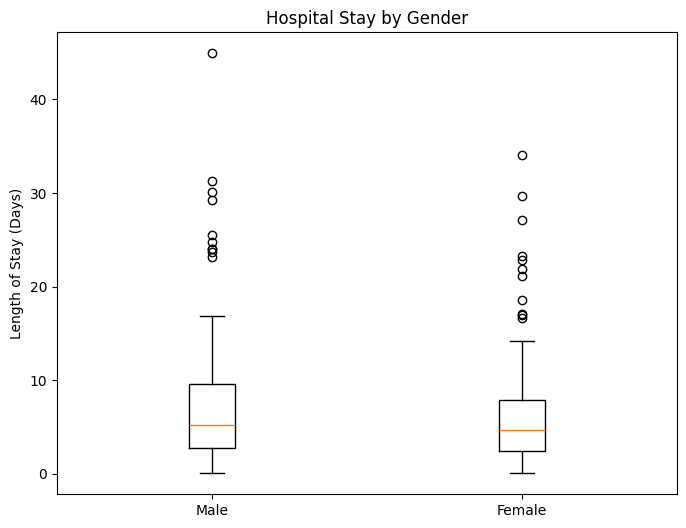

In [52]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [male["Length_of_Stay"], female["Length_of_Stay"]],
    labels=["Male", "Female"]
)

plt.ylabel("Length of Stay (Days)")
plt.title("Hospital Stay by Gender")
plt.show()


In [53]:
t_statistic, p_value = stats.ttest_ind(
    male["Length_of_Stay"],
    female["Length_of_Stay"],
    equal_var=False
)

print(f"T_statistic: {t_statistic}")
print(f"P_value: {p_value}")

T_statistic: 1.5257917914628134
P_value: 0.12823109651259804


### Interpretation
If the p-value is below 0.05, reject the null hypothesis. Otherwise, conclude that there is insufficient evidence to suggest a difference in average hospital stay between male and female patients.

## Research Question 4
### Does admission type influence average hospital stay? 

This analysis compares hospital stay across multiple admission categories. Since there are more than two groups, a one-way ANOVA is appropriate. 

In [54]:
groups = []
labels = []

for admission_type, group in df.groupby("admission_type"):
    groups.append(group["Length_of_Stay"].dropna())
    labels.append(admission_type)

F_statistic, p_value = stats.f_oneway(*groups)
print(f"F_statistic: {F_statistic}")
print(f"P_value: {p_value}")

F_statistic: 6.4259836968625486
P_value: 1.2199520685112606e-07


Text(0, 0.5, 'Length of Stay (Days)')

<Figure size 1200x600 with 0 Axes>

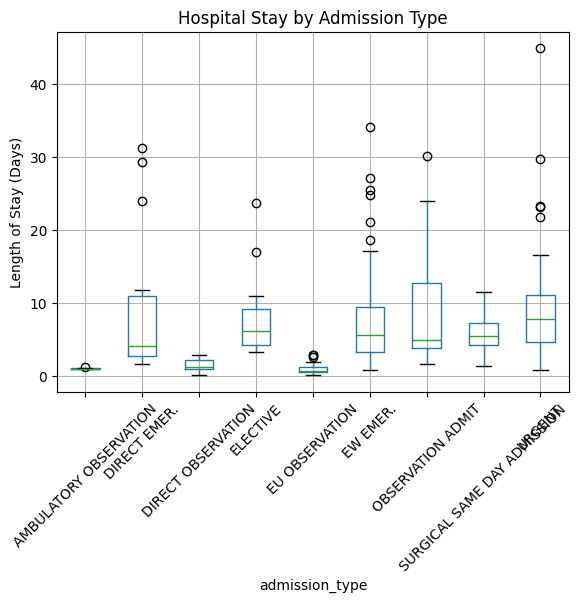

In [55]:
plt.figure(figsize=(12,6))

df.boxplot(
    column="Length_of_Stay",
    by="admission_type",
    rot=45
)

plt.title("Hospital Stay by Admission Type")
plt.suptitle("")
plt.ylabel("Length of Stay (Days)")

## Interpretation
Explain whether at least one admission type differs significantly from the others. 


## Research Question 5
### Is patient age associated with in-hospital mortality? 

Understanding whether deceased patients differ in age may provide insights into patient demographics and risk profiles. 

In [56]:
alive = df[
    df["hospital_expire_flag"]==0
]["anchor_age"]

deceased = df[
    df["hospital_expire_flag"]==1
]["anchor_age"]

/var/folders/xf/n8m4p5pj34v3rqg175l87xp40000gn/T/ipykernel_64323/3712994323.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


Text(0.5, 1.0, 'Age by Hospital Outcome')

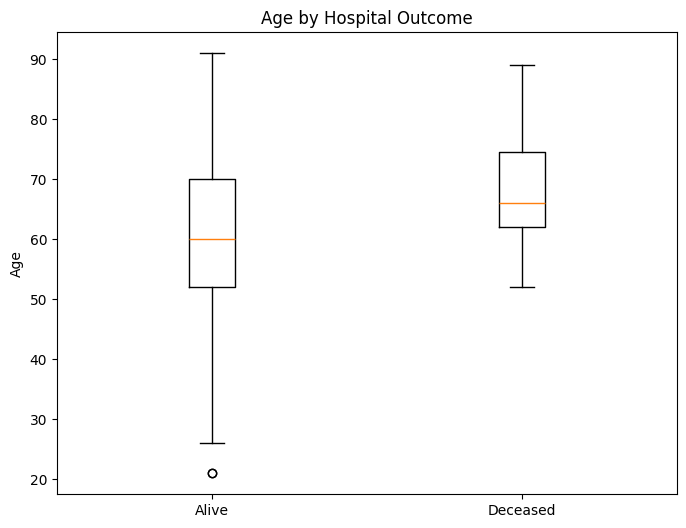

In [57]:
plt.figure(figsize=(8,6))

plt.boxplot(
    [alive,deceased],
    labels=["Alive", "Deceased"]
)

plt.ylabel("Age")
plt.title("Age by Hospital Outcome")

In [58]:
t_statistic, p_value = stats.ttest_ind(
    alive, 
    deceased, 
    equal_var=False
)

print(f"T_statistic: {t_statistic}")
print(f"P_value: {p_value}")

T_statistic: -2.5815144734487507
P_value: 0.01957056284251751


## Research Question 6
### Does insurance type influence hospital length of stay? 

Insurance groups may exhibit different hospitalization patterns due to patient demographics and healthcare utilization. This analysis compares average hospital sstay across insurance categories. 

In [59]:
insurance_groups = [
    group["Length_of_Stay"].dropna for _, group in df.groupby("insurance")
]

F_statistic, p_value = stats.f_oneway(*insurance_groups)
print(f"F_statistic: {F_statistic}")
print(f"p_value): {p_value}")

      




F_statistic: nan
p_value): nan


/Users/frank/DataLearning/dsenve/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4102: DegenerateDataWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if _f_oneway_is_too_small(samples):


Text(0, 0.5, 'Days')

<Figure size 1000x600 with 0 Axes>

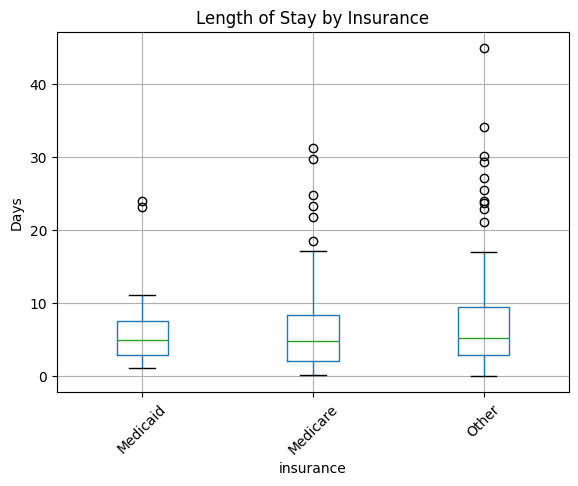

In [60]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="Length_of_Stay",
    by="insurance",
    rot=45
)

plt.title("Length of Stay by Insurance")
plt.suptitle("")
plt.ylabel("Days")

In [61]:
Q1 = df["Length_of_Stay"].quantile(.25)
Q3 = df["Length_of_Stay"].quantile(.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 

outliers = df[
    (df["Length_of_Stay"] < lower) | (df["Length_of_Stay"] > upper)
][["Length_of_Stay"]]

outliers

,Length_of_Stay
13,44.927778
26,29.706944
27,23.239583
34,21.834722
36,23.105556
45,23.683333
58,24.751389
69,21.111111
70,27.121528
79,25.538889


In [62]:
print(f"Lower Bound: {lower}")
print(f"Upper Bound: {upper}")
print("Number of Outliers: ", len(outliers))
print("Percentage: ", (len(outliers)/len(df))*100)

Lower Bound: -6.422569444444445
Upper Bound: 17.882986111111112
Number of Outliers:  18
Percentage:  6.545454545454546


Text(0.5, 0, 'Patients')

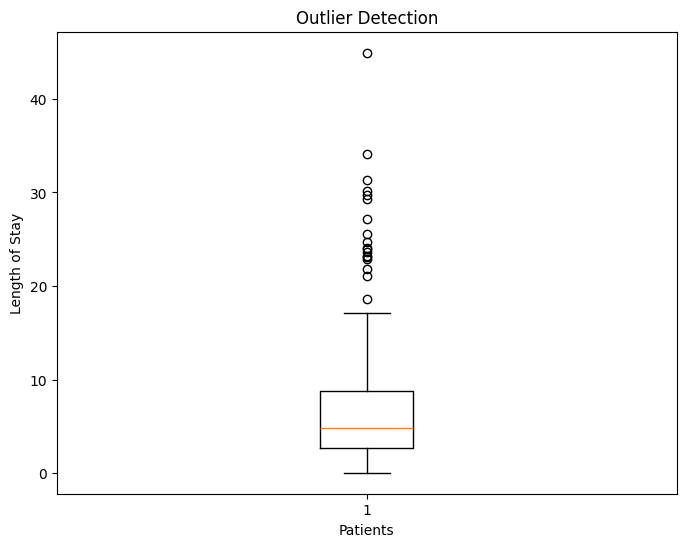

In [63]:
plt.figure(figsize=(8,6))
plt.boxplot(df["Length_of_Stay"])
plt.title("Outlier Detection")
plt.ylabel("Length of Stay")
plt.xlabel("Patients")


## Statistical Analysis Summary
The statistical analyses evaluated relationships among demographic characteristics, admission information, and hospital outcomes. 

Key observations included: 
- Relationship between patient age and hospital stay. 
- Differences between emergency and elective admissions. 
- Differences in hospital stay across admission categories.
- Age comparison between surviving and deceased patients.
- Differences across insurance groups. 
- Identification of extreme hospital stays for later review.

These findings guide feature selection and predictive model development in the next phase of the project. 

Text(0, 0.5, 'Frequency')

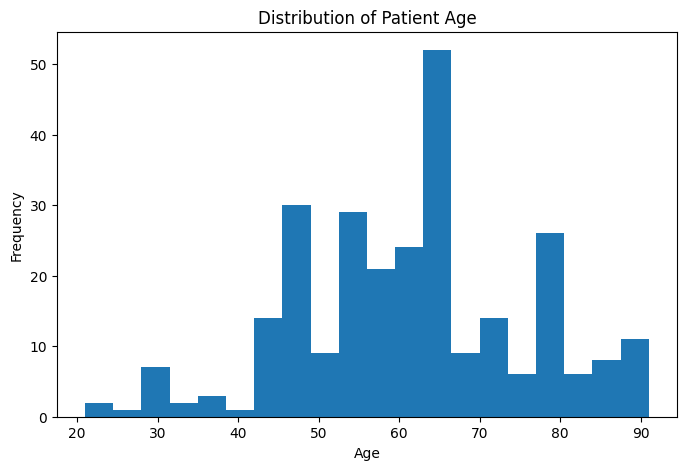

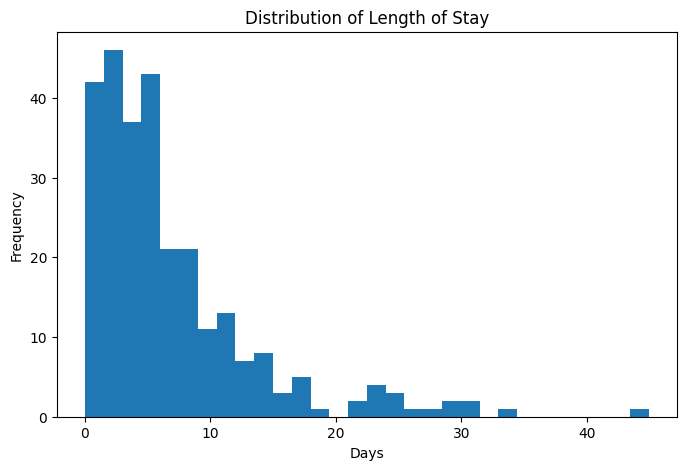

In [64]:
plt.figure(figsize=(8,5))
plt.hist(df["anchor_age"], bins=20)
plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.figure(figsize=(8,5))
plt.hist(df["Length_of_Stay"], bins=30)
plt.title("Distribution of Length of Stay")
plt.xlabel("Days")
plt.ylabel("Frequency")


## Q-Q Plot

Text(0.5, 1.0, 'Q-Q Plot: Patient Age')

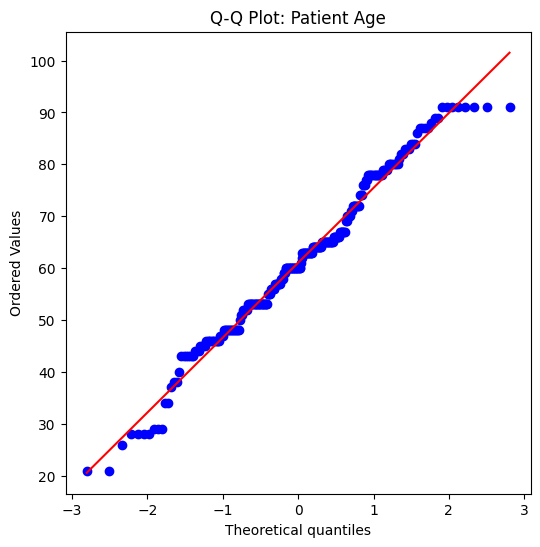

In [65]:
from scipy.stats import probplot 

plt.figure(figsize=(6,6))
probplot(df["anchor_age"], dist="norm", plot=plt)
plt.title("Q-Q Plot: Patient Age")

Text(0.5, 1.0, 'Q-Q Plot: Patient Age (Gamma Distribution)')

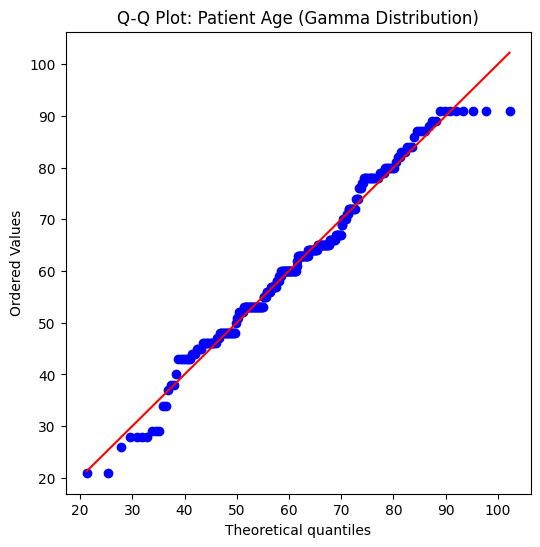

In [66]:
shape, loc, scale = stats.gamma.fit(df["anchor_age"])

plt.figure(figsize=(6,6))

# pass the shape parameter using sparams=(shape,)
probplot(df["anchor_age"], dist="gamma", sparams=(shape, loc, scale), plot=plt)

plt.title("Q-Q Plot: Patient Age (Gamma Distribution)")

Why am I getting the same graph for gamma distribution? I thought it'd be different from a normal distribution.

Text(0.5, 1.0, 'Q-Q Plot: Length of Stay')

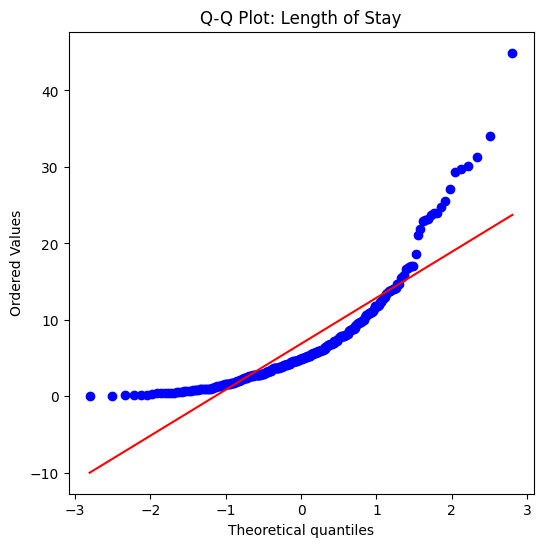

In [67]:
plt.figure(figsize=(6,6))
probplot(df["Length_of_Stay"], dist="norm", plot=plt)
plt.title("Q-Q Plot: Length of Stay")


- Points close to the line &rarr; approximately normal
- Large deviations &rarr; non-normal

## Shapiro-Wilk Test

In [68]:
age_stat, age_p = stats.shapiro(df["anchor_age"])

age_stat
age_p

np.float64(0.002370857269394115)

In [69]:
los_stat, los_p = stats.shapiro(df["Length_of_Stay"])

los_stat
los_p

np.float64(1.3633296482551042e-18)

### Interpretation
The Shapiro-Wilk test evaluates whether the data follow a normal distribution. 

Null hypothesis: 

The data are normally distributed.

Decision: 

If p > 0.05: 

Fail to reject the null hypothesis. 

If p < 0.05: 

Reject the null hypothesis.

For larger datasets, the Shapiro-Wilk test becomes extremely sensitive, so graphical methods (histograms and Q-Q plots) should also be considered. 

___Note: On large datasets, almost any small deviation from normality will produce a tiny p-value. That's why we don't realy on this test alone.___

In [70]:
emergency_los = emergency["Length_of_Stay"].dropna()
elective_los = elective["Length_of_Stay"].dropna()

levene_stat, levene_p = stats.levene(emergency_los, elective_los)

levene_stat
levene_p

np.float64(0.8884254463238379)

Interpretation:
- p > 0.05 &rarr; variances appear similar.
- p < 0.05 &rarr; variances differ.

## Selection of Statistical Tests

The statistical methods used in this project were selected based on the characteristics of the data and the research questions.

| Analysis | Test Used | Reason |
|-----------|-----------|--------|
| Age vs Length of Stay | Pearson Correlation | Evaluates linear association between two continuous variables. |
| Emergency vs Elective | Welch's t-test | Compares two independent groups without assuming equal variances. |
| Male vs Female | Welch's t-test | Appropriate for two independent groups with potentially unequal variances. |
| Admission Type | One-way ANOVA | Compares average length of stay across more than two groups. |
| Insurance | One-way ANOVA | Compares average length of stay across multiple insurance categories. |
| Mortality vs Age | Welch's t-test | Compares average age between two independent outcome groups. |
| Outlier Analysis | IQR Method | Identifies unusually long hospital stays that may influence analysis. |

In [71]:
u_stat, p_value = stats.mannwhitneyu(
    emergency,
    elective,
    alternative="two-sided"
)

u_stat
p_value

array([0.427448])

In [72]:
H_stat, p_value = stats.kruskal(*groups)

H_stat
p_value

np.float64(9.485853358636169e-18)

In [73]:
df.groupby("admission_type").size()

admission_type
AMBULATORY OBSERVATION           5
DIRECT EMER.                    15
DIRECT OBSERVATION               7
ELECTIVE                        13
EU OBSERVATION                  30
EW EMER.                       104
OBSERVATION ADMIT               45
SURGICAL SAME DAY ADMISSION     18
URGENT                          38
dtype: int64

In [74]:
df.groupby("insurance").size()

insurance
Medicaid     22
Medicare    104
Other       149
dtype: int64

## Assumption Assessment Summary

The assumptions underlying the statistical analyses were evaluated using graphical methods, formal statistical tests, and variance assessments. Continuous variables exhibited varying degrees of skewness, particularly hospital length of stay, which is typical of healthcare datasets. Accordingly, Welch's t-tests were selected for two-group comparisons because they are robust to unequal variances, and non-parametric tests (Mann–Whitney U and Kruskal–Wallis) were included as sensitivity analyses where appropriate. This approach increases confidence that the reported findings are not dependent on a single statistical method.

# Discussion & Key Findings
## Overview

The objective of this analysis was to investigate patient demographics, admission characteristics, and clinical outcomes within the MIMIC-IV Clinical Database Demo while identifying variables that may contribute to hospital resource utilization and future predictive modeling.

The analyses combined exploratory data analysis with inferential statistics to determine whether observed relationships were statistically meaningful. The following discussion summarizes the major findings and their implications for healthcare operations. 

## Patient Demographics

The patient population consisted of individuals with varying ages, genders, races, and insurance types. Descriptive statistics demonstrated the overall composition of the dataset and provided context for later analyses.

Understanding patient demographics is important because these variables frequently influence clinical outcomes, healthcare utilization, and predictive model performance. Age, gender, race, and insurance were therefore retained as potential predictive features for subsequent machine learning models.

## Hospital Operations

Admission characteristics were examined to better understand hospital utilization.
Emergency admissions represented a substantial portion of the dataset and generally exhibited different hospitalization patterns compared with elective admissions.

Length of stay varied across admission categories, suggesting that admission type may provide useful information when forecasting patient demand and hospital bed occupancy. These operational characteristics are highly relevant for hospital administrators responsible for staffing, scheduling, and resource allocation.

## Statistical Findings

Inferential statistical analyses were performed to determine whether observed relationships were statistically significant. The analyses investigated:

- Relationship between patient age and hospital length of stay
- Differences between emergency and elective admissions
- Gender differences in hospital stay
- Differences across admission types
- Differences across insurance categories
- Relationship between age and mortality

Where statistically significant relationships were identified, those variables were considered strong candidates for predictive modeling. Where no statistically significant relationship were observed, the results remained valuable because they indicated that the corresponding variable may contribute less predictive information.

## Outlier Assessment

Hospital length of stay exhibited several extreme observations. These cases likely represent patients requiring unusually complex care rather than simple data entry errors.

Rather than automatically removing these observations, they were retained because long hospital stays represent meaningful clinical events that future predictive models should learn to recognize. Outlier detection nevertheless provided valuable insight into the variability of hospital utilization.

## Missing Data

Missing values were examined during the data cleaning phase. Columns with missing observations were reviewed individually to determine appropriate handling strategies.

Where possible, missing values were retained or addressed using methods appropriate to the variable type rather than removing large portions of the dataset. Careful handling of missing data improves both statistical validity and machine learning performance.

## Limitations

Several limitations should be acknowledged.

The MIMIC-IV Clinical Database Demo represents only a small subset of the complete MIMIC-IV database. Consequently, some admission categories and demographic groups contain relatively few observations, reducing statistical power for certain analyses.

Furthermore, this project identifies statistical associations rather than causal relationships. Observed differences should therefore be interpreted as patterns within the dataset rather than evidence of cause-and-effect relationships.

## Conclusion

This exploratory and statistical analysis established a strong understanding of the patient population and hospital operations represented within the dataset.

Several variables demonstrated meaningful relationships with hospital utilization and clinical outcomes.

These findings provide a solid foundation for the development of predictive machine learning models in the next stage of the project.

# Preparing Data for Machine Learning
## Objective

The objective of this section is to prepare the cleaned dataset for predictive modeling. The preprocessing steps include: 
- Selecting relevant features
- Handling missing values
- Encoding categorical variables
- Scaling numerical features (where appropriate)
- Export a processed dataset for use in machine learning models

In [75]:
m1_df = df.copy()

selected_features = [
    "anchor_age",
    "gender",
    "admission_type", 
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",
    "admission_hour",
    "day_of_week",
    "Length_of_Stay",
    "admission_month"
]

m1_df = m1_df[selected_features]
m1_df

,anchor_age,gender,admission_type,admission_location,insurance,language,marital_status,race,admission_hour,day_of_week,Length_of_Stay,admission_month
0,47,M,URGENT,TRANSFER FROM HOSPITAL,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,14,Wednesday,8.975000,2
1,58,M,URGENT,TRANSFER FROM HOSPITAL,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,17,Monday,7.841667,9
2,79,M,URGENT,TRANSFER FROM HOSPITAL,Medicare,ENGLISH,MARRIED,WHITE,2,Wednesday,5.731250,8
3,52,M,URGENT,TRANSFER FROM HOSPITAL,Medicaid,ENGLISH,,UNKNOWN,23,Friday,1.736806,11
4,82,F,URGENT,TRANSFER FROM HOSPITAL,Other,ENGLISH,WIDOWED,WHITE,18,Friday,2.090972,8
...,...,...,...,...,...,...,...,...,...,...,...,...
270,70,M,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Medicare,ENGLISH,MARRIED,WHITE,1,Sunday,5.664583,7
271,43,F,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Other,ENGLISH,SINGLE,WHITE,1,Tuesday,4.512500,9
272,66,M,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Medicare,ENGLISH,MARRIED,WHITE,7,Wednesday,7.298611,3
273,65,M,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Medicare,ENGLISH,SINGLE,OTHER,11,Sunday,4.205556,12


In [76]:
m1_df = m1_df.dropna()
m1_df

,anchor_age,gender,admission_type,admission_location,insurance,language,marital_status,race,admission_hour,day_of_week,Length_of_Stay,admission_month
0,47,M,URGENT,TRANSFER FROM HOSPITAL,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,14,Wednesday,8.975000,2
1,58,M,URGENT,TRANSFER FROM HOSPITAL,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,17,Monday,7.841667,9
2,79,M,URGENT,TRANSFER FROM HOSPITAL,Medicare,ENGLISH,MARRIED,WHITE,2,Wednesday,5.731250,8
3,52,M,URGENT,TRANSFER FROM HOSPITAL,Medicaid,ENGLISH,,UNKNOWN,23,Friday,1.736806,11
4,82,F,URGENT,TRANSFER FROM HOSPITAL,Other,ENGLISH,WIDOWED,WHITE,18,Friday,2.090972,8
...,...,...,...,...,...,...,...,...,...,...,...,...
270,70,M,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Medicare,ENGLISH,MARRIED,WHITE,1,Sunday,5.664583,7
271,43,F,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Other,ENGLISH,SINGLE,WHITE,1,Tuesday,4.512500,9
272,66,M,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Medicare,ENGLISH,MARRIED,WHITE,7,Wednesday,7.298611,3
273,65,M,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Medicare,ENGLISH,SINGLE,OTHER,11,Sunday,4.205556,12


In [77]:
m1_df = pd.get_dummies(
    m1_df,
    columns=[
        "gender", 
        "admission_type", 
        "admission_location",
        "insurance",
        "language",
        "marital_status",
        "race",
        "day_of_week"
    ],
    drop_first = True
)

m1_df.head()

,anchor_age,admission_hour,Length_of_Stay,admission_month,gender_M,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,...,race_UNKNOWN,race_WHITE,race_WHITE - BRAZILIAN,race_WHITE - OTHER EUROPEAN,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,47,14,8.975000,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,58,17,7.841667,9,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,79,2,5.731250,8,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,52,23,1.736806,11,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,82,18,2.090972,8,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [78]:
m1_df.shape

(275, 48)

In [79]:
print(m1_df.columns.tolist())

['anchor_age', 'admission_hour', 'Length_of_Stay', 'admission_month', 'gender_M', 'admission_type_DIRECT EMER.', 'admission_type_DIRECT OBSERVATION', 'admission_type_ELECTIVE', 'admission_type_EU OBSERVATION', 'admission_type_EW EMER.', 'admission_type_OBSERVATION ADMIT', 'admission_type_SURGICAL SAME DAY ADMISSION', 'admission_type_URGENT', 'admission_location_EMERGENCY ROOM', 'admission_location_INFORMATION NOT AVAILABLE', 'admission_location_INTERNAL TRANSFER TO OR FROM PSYCH', 'admission_location_PACU', 'admission_location_PHYSICIAN REFERRAL', 'admission_location_PROCEDURE SITE', 'admission_location_TRANSFER FROM HOSPITAL', 'admission_location_TRANSFER FROM SKILLED NURSING FACILITY', 'admission_location_WALK-IN/SELF REFERRAL', 'insurance_Medicare', 'insurance_Other', 'language_ENGLISH', 'marital_status_DIVORCED', 'marital_status_MARRIED', 'marital_status_SINGLE', 'marital_status_WIDOWED', 'race_BLACK/CAPE VERDEAN', 'race_HISPANIC OR LATINO', 'race_HISPANIC/LATINO - CUBAN', 'race_HI

In [ ]:
x = m1_df.drop(
    columns=["Length_of_Stay"]
)

y = m1_df["Length_of_Stay"]

In [ ]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)



In [82]:
m1_df

,anchor_age,admission_hour,Length_of_Stay,admission_month,gender_M,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,...,race_UNKNOWN,race_WHITE,race_WHITE - BRAZILIAN,race_WHITE - OTHER EUROPEAN,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,47,14,8.975000,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,58,17,7.841667,9,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,79,2,5.731250,8,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,52,23,1.736806,11,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,82,18,2.090972,8,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,70,1,5.664583,7,True,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
271,43,1,4.512500,9,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
272,66,7,7.298611,3,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
273,65,11,4.205556,12,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [125]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numerical_features = [
    "anchor_age", 
    "admission_month", 
    "admission_hour"
]

In [143]:
X_train[numerical_features] = X_train[numerical_features].astype(float)
X_test[numerical_features] = X_test[numerical_features].astype(float)

X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)


In [144]:
X_train

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,...,marital_status,race,hospital_expire_flag,admission_year,admission_month,admission_week,day_of_week,week_num,week_of_month,admission_hour
10,10037861,M,1.067396,2115,24256866,2115-10-09 20:28:00,2115-10-18 16:50:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,...,MARRIED,UNKNOWN,0,2115,1.003169,2,Wednesday,2,second,0.909778
260,10039831,F,-0.272559,2115,26924951,2115-12-28 07:15:00,2116-01-02 14:34:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,MARRIED,UNABLE TO OBTAIN,0,2115,1.614518,5,Saturday,4,fourth,-0.850685
267,10025612,M,1.402385,2125,23403708,2125-09-25 07:15:00,2125-10-03 12:24:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,MARRIED,WHITE,0,2125,0.697494,1,Tuesday,4,fourth,-0.850685
33,10002930,F,-0.875539,2193,22733922,2198-04-22 16:17:00,2198-05-04 13:20:00,URGENT,INTERNAL TRANSFER TO OR FROM PSYCH,HOME,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2198,-0.830879,6,Sunday,4,fourth,0.368097
222,10039708,F,-1.009534,2138,29488258,2144-01-19 12:07:00,2144-01-21 21:20:00,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2144,-1.747903,6,Sunday,3,third,-0.173584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,10012853,F,2.005365,2175,22896692,2176-08-11 15:17:00,2176-08-11 17:35:00,EU OBSERVATION,EMERGENCY ROOM,,...,WIDOWED,BLACK/AFRICAN AMERICAN,0,2176,0.391819,6,Sunday,2,second,0.232677
71,10032725,F,-1.545516,2143,20611640,2143-03-22 04:59:00,2143-03-25 13:00:00,EW EMER.,EMERGENCY ROOM,HOSPICE,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2143,-1.136554,4,Friday,4,fourth,-1.256946
106,10026406,M,-1.076532,2129,25260176,2129-01-03 15:55:00,2129-01-05 14:10:00,EW EMER.,EMERGENCY ROOM,AGAINST ADVICE,...,DIVORCED,WHITE,0,2129,-1.747903,0,Monday,1,first,0.232677
270,10038992,M,0.598412,2185,24745425,2187-07-29 01:05:00,2187-08-03 17:02:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,...,MARRIED,WHITE,0,2187,0.086145,6,Sunday,5,fifth,-1.663207


In [145]:
# Use .loc[:, columns] to safely assign the values
# X_train.loc[:, numerical_features] = scaler.fit_transform(X_train[numerical_features])
# X_test.loc[:, numerical_features] = scaler.transform(X_test[numerical_features])

In [140]:
X_train

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,...,marital_status,race,hospital_expire_flag,admission_year,admission_month,admission_week,day_of_week,week_num,week_of_month,admission_hour
10,10037861,M,1.067396,2115,24256866,2115-10-09 20:28:00,2115-10-18 16:50:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,...,MARRIED,UNKNOWN,0,2115,1.003169,2,Wednesday,2,second,0.909778
260,10039831,F,-0.272559,2115,26924951,2115-12-28 07:15:00,2116-01-02 14:34:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,MARRIED,UNABLE TO OBTAIN,0,2115,1.614518,5,Saturday,4,fourth,-0.850685
267,10025612,M,1.402385,2125,23403708,2125-09-25 07:15:00,2125-10-03 12:24:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,MARRIED,WHITE,0,2125,0.697494,1,Tuesday,4,fourth,-0.850685
33,10002930,F,-0.875539,2193,22733922,2198-04-22 16:17:00,2198-05-04 13:20:00,URGENT,INTERNAL TRANSFER TO OR FROM PSYCH,HOME,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2198,-0.830879,6,Sunday,4,fourth,0.368097
222,10039708,F,-1.009534,2138,29488258,2144-01-19 12:07:00,2144-01-21 21:20:00,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2144,-1.747903,6,Sunday,3,third,-0.173584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,10012853,F,2.005365,2175,22896692,2176-08-11 15:17:00,2176-08-11 17:35:00,EU OBSERVATION,EMERGENCY ROOM,,...,WIDOWED,BLACK/AFRICAN AMERICAN,0,2176,0.391819,6,Sunday,2,second,0.232677
71,10032725,F,-1.545516,2143,20611640,2143-03-22 04:59:00,2143-03-25 13:00:00,EW EMER.,EMERGENCY ROOM,HOSPICE,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2143,-1.136554,4,Friday,4,fourth,-1.256946
106,10026406,M,-1.076532,2129,25260176,2129-01-03 15:55:00,2129-01-05 14:10:00,EW EMER.,EMERGENCY ROOM,AGAINST ADVICE,...,DIVORCED,WHITE,0,2129,-1.747903,0,Monday,1,first,0.232677
270,10038992,M,0.598412,2185,24745425,2187-07-29 01:05:00,2187-08-03 17:02:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,...,MARRIED,WHITE,0,2187,0.086145,6,Sunday,5,fifth,-1.663207


In [85]:
X_train.shape

(220, 47)

In [86]:
X_test.shape


(55, 47)

In [87]:
y_train.shape


(220,)

In [88]:
y_test.shape

(55,)

In [195]:
from pathlib import Path

# Path.home() automatically starts at '/Users/frank'
target_dir = Path.home() / "data science projects" / "Healthcare-Demand-Forecasting" / "data" / "processed"

# Force the folder to be created safely if it's missing
target_dir.mkdir(parents=True, exist_ok=True)

# Define your final file path and save!
output_path = target_dir / "processed_patient_data.csv"
df.to_csv(output_path, index=False)

print(f"✅ Saved perfectly at: {output_path}")

✅ Saved perfectly at: /Users/frank/data science projects/Healthcare-Demand-Forecasting/data/processed/processed_patient_data.csv


## Upgrade the Project
- Use ColumnTransformer and Pipeline to automate additional incoming data.


In [156]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression



In [194]:
x

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,...,marital_status,race,hospital_expire_flag,admission_year,admission_month,admission_week,day_of_week,week_num,week_of_month,admission_hour
0,10004235,M,47,2196,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,SINGLE,BLACK/CAPE VERDEAN,0,2196,2,2,Wednesday,4,fourth,14
1,10009628,M,58,2153,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,...,MARRIED,HISPANIC/LATINO - PUERTO RICAN,0,2153,9,0,Monday,3,third,17
2,10018081,M,79,2133,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,MARRIED,WHITE,0,2134,8,2,Wednesday,3,third,2
3,10006053,M,52,2111,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,URGENT,TRANSFER FROM HOSPITAL,DIED,...,,UNKNOWN,1,2111,11,4,Friday,2,second,23
4,10031404,F,82,2113,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,URGENT,TRANSFER FROM HOSPITAL,HOME,...,WIDOWED,WHITE,0,2113,8,4,Friday,1,first,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,10038992,M,70,2185,24745425,2187-07-29 01:05:00,2187-08-03 17:02:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,...,MARRIED,WHITE,0,2187,7,6,Sunday,5,fifth,1
271,10008287,F,43,2145,22168393,2145-09-28 01:17:00,2145-10-02 13:35:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,SINGLE,WHITE,0,2145,9,1,Tuesday,4,fourth,1
272,10022880,M,66,2177,27708593,2177-03-12 07:15:00,2177-03-19 14:25:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME,...,MARRIED,WHITE,0,2177,3,2,Wednesday,2,second,7
273,10004457,M,65,2140,23251352,2141-12-17 11:00:00,2141-12-21 15:56:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,REHAB,...,SINGLE,OTHER,0,2141,12,6,Sunday,3,third,11


In [157]:
x = df.drop(columns=["Length_of_Stay"])
y = df["Length_of_Stay"]

numeric_features = [
    "anchor_age",
    "admission_month",
    "admission_hour"
]

categorical_features = [
    "gender",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",
    "day_of_week"
]


In [158]:
x

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,...,marital_status,race,hospital_expire_flag,admission_year,admission_month,admission_week,day_of_week,week_num,week_of_month,admission_hour
0,10004235,M,47,2196,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,SINGLE,BLACK/CAPE VERDEAN,0,2196,2,2,Wednesday,4,fourth,14
1,10009628,M,58,2153,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,...,MARRIED,HISPANIC/LATINO - PUERTO RICAN,0,2153,9,0,Monday,3,third,17
2,10018081,M,79,2133,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,MARRIED,WHITE,0,2134,8,2,Wednesday,3,third,2
3,10006053,M,52,2111,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,URGENT,TRANSFER FROM HOSPITAL,DIED,...,,UNKNOWN,1,2111,11,4,Friday,2,second,23
4,10031404,F,82,2113,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,URGENT,TRANSFER FROM HOSPITAL,HOME,...,WIDOWED,WHITE,0,2113,8,4,Friday,1,first,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,10038992,M,70,2185,24745425,2187-07-29 01:05:00,2187-08-03 17:02:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,...,MARRIED,WHITE,0,2187,7,6,Sunday,5,fifth,1
271,10008287,F,43,2145,22168393,2145-09-28 01:17:00,2145-10-02 13:35:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,SINGLE,WHITE,0,2145,9,1,Tuesday,4,fourth,1
272,10022880,M,66,2177,27708593,2177-03-12 07:15:00,2177-03-19 14:25:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME,...,MARRIED,WHITE,0,2177,3,2,Wednesday,2,second,7
273,10004457,M,65,2140,23251352,2141-12-17 11:00:00,2141-12-21 15:56:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,REHAB,...,SINGLE,OTHER,0,2141,12,6,Sunday,3,third,11


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False, # to bypass encoder defaulting to sparse matrix
                drop="first" # apparently, for one-hot encoding the drop="first" gets rid of the redundant column, if not, starts dividing by zero and get warnings in model prediction
            )
        )
    ]
)



In [186]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

preprocessor.set_output(transform="pandas")


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['anchor_age', 'admission_month',
                                  'admission_hour']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'admission_type',
                                  'admission_location', 'insurance', 'language',
                                  'marital_status', 'race', 'day_of_week'])])

In [187]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


In [188]:
X_train_processed

,num__anchor_age,num__admission_month,num__admission_hour,cat__gender_M,cat__admission_type_DIRECT EMER.,cat__admission_type_DIRECT OBSERVATION,cat__admission_type_ELECTIVE,cat__admission_type_EU OBSERVATION,cat__admission_type_EW EMER.,cat__admission_type_OBSERVATION ADMIT,...,cat__race_UNKNOWN,cat__race_WHITE,cat__race_WHITE - BRAZILIAN,cat__race_WHITE - OTHER EUROPEAN,cat__day_of_week_Monday,cat__day_of_week_Saturday,cat__day_of_week_Sunday,cat__day_of_week_Thursday,cat__day_of_week_Tuesday,cat__day_of_week_Wednesday
10,1.067396,1.003169,0.909778,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
260,-0.272559,1.614518,-0.850685,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
267,1.402385,0.697494,-0.850685,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
33,-0.875539,-0.830879,0.368097,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
222,-1.009534,-1.747903,-0.173584,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,2.005365,0.391819,0.232677,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
71,-1.545516,-1.136554,-1.256946,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106,-1.076532,-1.747903,0.232677,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
270,0.598412,0.086145,-1.663207,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [192]:
X_train

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,...,marital_status,race,hospital_expire_flag,admission_year,admission_month,admission_week,day_of_week,week_num,week_of_month,admission_hour
10,10037861,M,77,2115,24256866,2115-10-09 20:28:00,2115-10-18 16:50:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,...,MARRIED,UNKNOWN,0,2115,10,2,Wednesday,2,second,20
260,10039831,F,57,2115,26924951,2115-12-28 07:15:00,2116-01-02 14:34:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,MARRIED,UNABLE TO OBTAIN,0,2115,12,5,Saturday,4,fourth,7
267,10025612,M,82,2125,23403708,2125-09-25 07:15:00,2125-10-03 12:24:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,MARRIED,WHITE,0,2125,9,1,Tuesday,4,fourth,7
33,10002930,F,48,2193,22733922,2198-04-22 16:17:00,2198-05-04 13:20:00,URGENT,INTERNAL TRANSFER TO OR FROM PSYCH,HOME,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2198,4,6,Sunday,4,fourth,16
222,10039708,F,46,2138,29488258,2144-01-19 12:07:00,2144-01-21 21:20:00,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2144,1,6,Sunday,3,third,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,10012853,F,91,2175,22896692,2176-08-11 15:17:00,2176-08-11 17:35:00,EU OBSERVATION,EMERGENCY ROOM,,...,WIDOWED,BLACK/AFRICAN AMERICAN,0,2176,8,6,Sunday,2,second,15
71,10032725,F,38,2143,20611640,2143-03-22 04:59:00,2143-03-25 13:00:00,EW EMER.,EMERGENCY ROOM,HOSPICE,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2143,3,4,Friday,4,fourth,4
106,10026406,M,45,2129,25260176,2129-01-03 15:55:00,2129-01-05 14:10:00,EW EMER.,EMERGENCY ROOM,AGAINST ADVICE,...,DIVORCED,WHITE,0,2129,1,0,Monday,1,first,15
270,10038992,M,70,2185,24745425,2187-07-29 01:05:00,2187-08-03 17:02:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,...,MARRIED,WHITE,0,2187,7,6,Sunday,5,fifth,1


In [189]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

model.fit(X_train, y_train)




Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['anchor_age',
                                                   'admission_month',
                                                   'admission_hour']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'admission_type',
                                                   'admission_location',
                                                   'insurance', 'language',
                                                   'marital_status', 'race',
                                                   'day_of_week'])])),
                ('regressor', LinearRegression())])

In [193]:
from sklearn.metrics import r2_score, mean_absolute_error

y_train_pred = model.predict(X_train)

print(f"R² Score (Variance Explained): {r2_score(y_train, y_train_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_train, y_train_pred):.4f}")



R² Score (Variance Explained): 0.2791
Mean Absolute Error: 3.9081


/Users/frank/DataLearning/dsenve/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/frank/DataLearning/dsenve/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/frank/DataLearning/dsenve/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
